# Isolation Forest 

Imagine all stock-days as points in space. Isolation Forest makes random cuts through that space and counts how many cuts it takes to isolate each point. Anomalies sit off alone in seperate regions, so they isolate in few cuts; normal points buried in the dense crowd take many. Few cuts = anomalous

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data")
features = pd.read_parquet(DATA_DIR / "features_clean.parquet")

feature_cols = ["ret_zscore", "vol_5", "vol_20", "vol_60", "vol_zscore"]
print(features.shape)
features[feature_cols].head()

(1184191, 5)


ret_zscore     vol_5    vol_20    vol_60  vol_zscore
Date       Ticker                                                      
2015-03-31 A        -0.265168  0.010081  0.012667  0.014717   -0.410469
           AAPL     -0.938535  0.020079  0.014414  0.017461   -0.650943
           ABBV      0.313153  0.015404  0.019325  0.020973   -0.017244
           ABT      -1.348220  0.009937  0.011308  0.011799    0.387669
           ACGL     -2.030660  0.011328  0.009421  0.008541    2.016447

# Testing Isolation forest

Making Isolation Forest program step by step. 


In [22]:
import numpy as np


def isolation_depth(X, point, current_depth=0, max_depth=20):
    """
    How many random splits to isolate point at point_idx within day X
    X: 2D Array (rows = points, columns = features)
    Reutrns: depth of which the point becomes isolated
    """

    n = len(X)

    # Base case 1: point is alone (isolated) -> stop
    if n<=1:
        return current_depth
    
    # Base case 2: safety cap so we don't recurse forever
    if current_depth >= max_depth:
        return current_depth
    
    # Pick a random feature to split on
    feature = np.random.randint(0, X.shape[1])

    # Pick a random split value between that feature's min and max 
    feat_min, feat_max = X[:, feature].min(), X[:, feature].max()
    if feat_min == feat_max:
        # If all values are the same, we can't split on this feature
        return current_depth
    split = np.random.uniform(feat_min, feat_max)

    # Which side is our target point on?
    if point[feature] < split:
        subset = X[X[:, feature] < split]      # keep only left side
    else:
        subset = X[X[:, feature] >= split]     # keep only right side

    return isolation_depth(subset, point, current_depth + 1, max_depth)


## Testing the above function on dummy dataset

In [23]:
toy = np.array([[0.1], [0.3], [-0.2], [0.4], [5.0]])   # one feature, 5 points

outlier = np.array([5.0])
normal  = np.array([0.3])

# run many times and average, since each run is random
out_depths = [isolation_depth(toy, outlier) for _ in range(1000)]
norm_depths = [isolation_depth(toy, normal) for _ in range(1000)]

print("Avg depth to isolate the OUTLIER (5.0):", np.mean(out_depths))
print("Avg depth to isolate a NORMAL point (0.3):", np.mean(norm_depths))

Avg depth to isolate the OUTLIER (5.0): 1.135
Avg depth to isolate a NORMAL point (0.3): 3.595


## So I have to cut this data set on an average once to get to 5, but 3.5 times to get to 0.3

Now, implementing this idea on the data set to catch anomalies based on the 5 features of data paraquets created from the 499 companies. 

In [24]:
from sklearn.ensemble import IsolationForest

feature_cols = ["ret_zscore", "vol_5", "vol_20", "vol_60", "vol_zscore"]
X = features[feature_cols].values

iso = IsolationForest(
    n_estimators=100,
    contamination=0.007,
    random_state=42,
    n_jobs=-1,
)

iso.fit(X)

features["iso_score"] = iso.decision_function(X)
features["iso_anomaly"] = iso.predict(X) == -1

n_flagged = features["iso_anomaly"].sum()
print(f"Flagged {n_flagged} of {len(features)} stock-days ({100*n_flagged/len(features):.2f}%)")

Flagged 8290 of 1184191 stock-days (0.70%)


## Now checking for overlapping anomalies

In [25]:
# load detector 1's output
d1 = pd.read_parquet(DATA_DIR / "detector1_statistical.parquet")
features["stat_anomaly"] = d1["stat_anomaly"]

both  = (features["stat_anomaly"] & features["iso_anomaly"]).sum()
stat_only = (features["stat_anomaly"] & ~features["iso_anomaly"]).sum()
iso_only  = (~features["stat_anomaly"] & features["iso_anomaly"]).sum()

print(f"Flagged by BOTH:            {both}")
print(f"Flagged by ±3σ ONLY:        {stat_only}")
print(f"Flagged by IsoForest ONLY:  {iso_only}")
print(f"Overlap: {100*both/features['stat_anomaly'].sum():.1f}% of baseline flags")

Flagged by BOTH:            1146
Flagged by ±3σ ONLY:        7152
Flagged by IsoForest ONLY:  7144
Overlap: 13.8% of baseline flags


## The gap is huge!

They only overlap about 13.8% (for 7 days, both agree that one day is anomolous).
This helps out with the RQ. 

To test what's going on, I'll look in deeper. A year by year sum of corresponding data. 

## Isolation forest flags by year:

In [26]:
iso_only_days = features[~features["stat_anomaly"] & features["iso_anomaly"]]
print("IsoForest-only flags by year:")
print(iso_only_days.groupby(iso_only_days.index.get_level_values("Date").year).size())

IsoForest-only flags by year:
Date
2015      40
2016     183
2017      16
2018      96
2019     140
2020    5379
2021      84
2022     673
2023     276
2024     257
dtype: int64


## Stats flags by year:

In [27]:
stat_only_days = features[features["stat_anomaly"] & ~features["iso_anomaly"]]
print("\n±3σ-only flags by year:")
print(stat_only_days.groupby(stat_only_days.index.get_level_values("Date").year).size())


±3σ-only flags by year:
Date
2015     485
2016     900
2017    1010
2018     918
2019     679
2020     555
2021     568
2022     369
2023     722
2024     946
dtype: int64


## Feature averages - IsoForest-only flags vs. overall

In [28]:
print("Feature averages - IsoForest-only flags vs. overall:")
print(iso_only_days[feature_cols].mean())
print("\nOverall dataset averages:")
print(features[feature_cols].mean())

Feature averages - IsoForest-only flags vs. overall:
ret_zscore    0.081052
vol_5         0.090212
vol_20        0.087229
vol_60        0.069591
vol_zscore    0.075469
dtype: float64

Overall dataset averages:
ret_zscore   -0.013781
vol_5         0.016353
vol_20        0.017709
vol_60        0.018364
vol_zscore   -0.011265
dtype: float64


## Using abs values for ret_scores because they have negetive values. Average would cancel out alot of datas. To actually see if the deviations in difference featues are corresponding to one another or not. 

In [29]:
print("IsoForest-only — mean ABSOLUTE z-scores:")
print(iso_only_days[["ret_zscore", "vol_zscore"]].abs().mean())
print("\nOverall — mean ABSOLUTE z-scores:")
print(features[["ret_zscore", "vol_zscore"]].abs().mean())

IsoForest-only — mean ABSOLUTE z-scores:
ret_zscore    0.947029
vol_zscore    1.043464
dtype: float64

Overall — mean ABSOLUTE z-scores:
ret_zscore    0.756419
vol_zscore    0.829443
dtype: float64


## Forest-only flags show volatility levels ~5× the dataset average while mean absolute return z-scores remain near baseline (0.95 vs 0.76 overall) — well below the ±3σ threshold of 3.0. This rules out the possibility that extreme returns were masked by sign cancellation in the averaging, and confirms the Isolation Forest is detecting rarity of volatility state rather than daily return surprise. The two detectors are orthogonal instruments: the baseline measures surprise relative to recent behavior; the forest measures rarity of feature-space position.

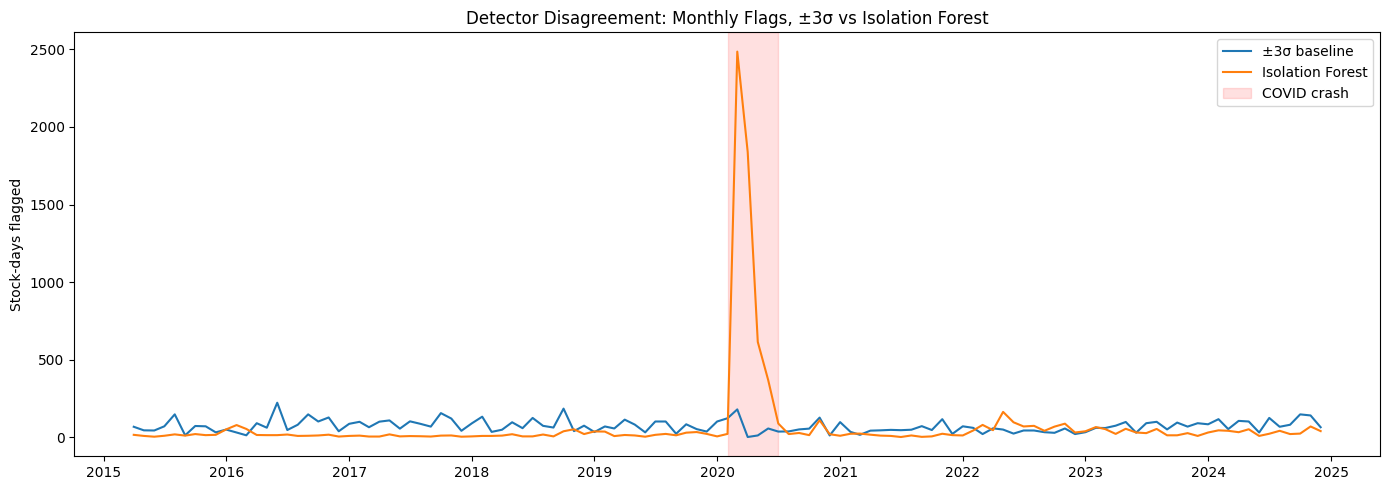

In [30]:
import matplotlib.pyplot as plt

dates = features.index.get_level_values("Date")
monthly_stat = features[features["stat_anomaly"]].groupby(
    features[features["stat_anomaly"]].index.get_level_values("Date").to_period("M")).size()
monthly_iso = features[features["iso_anomaly"]].groupby(
    features[features["iso_anomaly"]].index.get_level_values("Date").to_period("M")).size()

monthly_stat.index = monthly_stat.index.to_timestamp()
monthly_iso.index = monthly_iso.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_stat.index, monthly_stat.values, label="±3σ baseline", linewidth=1.5)
ax.plot(monthly_iso.index, monthly_iso.values, label="Isolation Forest", linewidth=1.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"),
           color="red", alpha=0.12, label="COVID crash")
ax.set_title("Detector Disagreement: Monthly Flags, ±3σ vs Isolation Forest")
ax.set_ylabel("Stock-days flagged")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("../results/detector_disagreement_monthly.png", dpi=150, bbox_inches="tight")

### Detector Disagreement Over Time

Both detectors flag about the same number of days overall, so this shows *when*
each one fires. They track each other loosely for most of the decade — until
March 2020, when they split completely.

The Isolation Forest jumps to ~2,500 flagged days in one month, about 15× its
normal rate. The ±3σ baseline doesn't react at all — it stays flat, no different
from any other month.

**Why:** the baseline compares each day's return to that stock's *recent*
volatility. By March 2020, big moves had been happening for weeks, so they'd
become the new normal and stopped looking surprising. The Isolation Forest reads
volatility levels directly, so it sees the crash.

**Takeaway:** the biggest market event of the decade is nearly invisible to one
detector and overwhelming to the other.

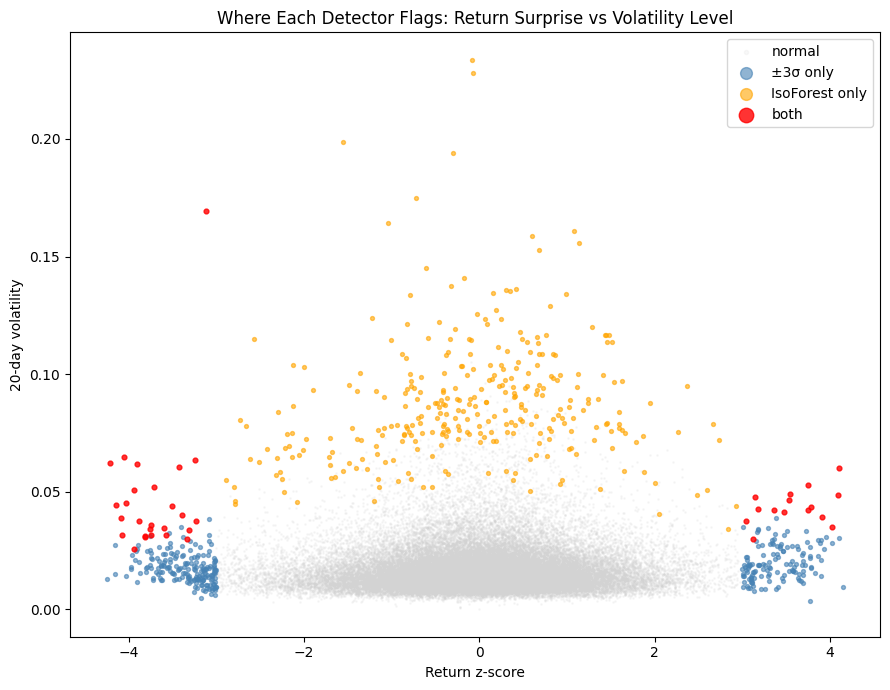

In [31]:
sample = features.sample(50000, random_state=42)   # subsample so it renders

fig, ax = plt.subplots(figsize=(9, 7))
normal = sample[~sample["stat_anomaly"] & ~sample["iso_anomaly"]]
ax.scatter(normal["ret_zscore"], normal["vol_20"], s=1, alpha=0.15, color="lightgray", label="normal")

s_only = sample[sample["stat_anomaly"] & ~sample["iso_anomaly"]]
ax.scatter(s_only["ret_zscore"], s_only["vol_20"], s=8, alpha=0.6, color="steelblue", label="±3σ only")

i_only = sample[~sample["stat_anomaly"] & sample["iso_anomaly"]]
ax.scatter(i_only["ret_zscore"], i_only["vol_20"], s=8, alpha=0.6, color="orange", label="IsoForest only")

both_f = sample[sample["stat_anomaly"] & sample["iso_anomaly"]]
ax.scatter(both_f["ret_zscore"], both_f["vol_20"], s=12, alpha=0.8, color="red", label="both")

ax.set_xlabel("Return z-score")
ax.set_ylabel("20-day volatility")
ax.set_title("Where Each Detector Flags: Return Surprise vs Volatility Level")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()
fig.savefig("../results/detector_feature_space.png", dpi=150, bbox_inches="tight")

### Where Each Detector Flags

Each dot is a stock-day, placed by its return z-score (x-axis) and 20-day
volatility (y-axis). Gray = flagged by neither, blue = ±3σ only, orange =
Isolation Forest only, red = both.

The shapes say it all. **Blue forms two vertical stripes** on the far left and
right — the baseline fires on extreme returns no matter the volatility, cutting
the space *vertically*. **Orange forms a horizontal band along the top** — high
volatility with ordinary returns, cutting the space *horizontally*.

The two detectors slice the same space along perpendicular lines. Red (agreement)
only appears in the corners, where a day is extreme on *both* at once — which is
rare.

**Takeaway:** these detectors ask different questions. One finds return surprises,
the other finds unusual volatility states. Neither is wrong.

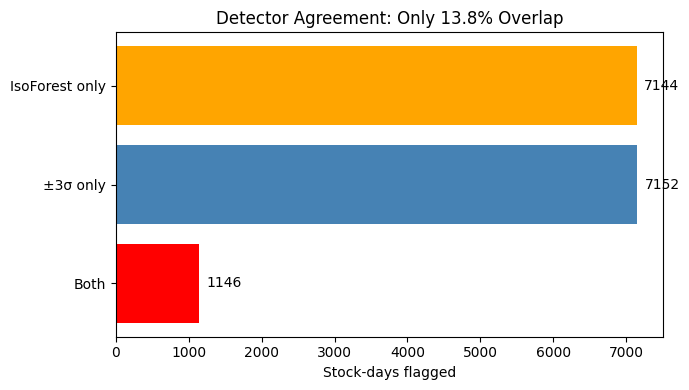

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(["Both", "±3σ only", "IsoForest only"], [1146, 7152, 7144],
        color=["red", "steelblue", "orange"])
ax.set_xlabel("Stock-days flagged")
ax.set_title("Detector Agreement: Only 13.8% Overlap")
for i, v in enumerate([1146, 7152, 7144]):
    ax.text(v + 100, i, str(v), va="center")
plt.tight_layout()
plt.show()
fig.savefig("../results/detector_overlap.png", dpi=150, bbox_inches="tight")

### Detector Agreement: 13.8% Overlap

Both detectors flag ~8,300 days, so any difference is about *which* days they
pick, not how many.

Only **1,146 days are flagged by both** — 13.8%. The other ~14,300 flagged days
are disagreements: 7,152 caught only by ±3σ, 7,144 only by the Isolation Forest.

**Takeaway:** they agree on about one day in seven. That's good news — it leaves
~14,300 disagreement cases to test in the event study.

## Summary: Detector 2 (Isolation Forest)

**What I did.** Fitted one Isolation Forest (100 trees) across all 499 tickers on
the five-feature matrix (~1.18M stock-days). Set `contamination` to 0.007 so it
flags the same rate as the ±3σ baseline — that way any difference is about *which*
days, not *how many*.

**What I found.** The two detectors agree on only **13.8%** of flagged days. The
disagreement is almost entirely a 2020 story: **75% of forest-only flags (5,379 of
7,144)** land in that year, about 40× the neighboring years. Meanwhile ±3σ-only
flags stay flat all decade.

**Three checks that confirm the cause:**
1. Timing — forest-only flags pile up in 2020.
2. Features — those days show volatility ~5× the normal level, but ordinary returns.
3. Magnitude — their average |return z-score| is 0.95, way below the ±3σ cutoff of
   3.0. So it's not extreme returns cancelling out in the average; the returns
   really were tame.

**What it means.** The ±3σ rule measures **surprise vs. recent behavior**. The
Isolation Forest measures **how rare a day's overall state is**. A sustained crisis
is a rare state made of unsurprising days — which is why the baseline goes silent
in April 2020 (1 flag) while the forest fires nonstop. They're not redundant;
they're looking at different things.

**Why this matters.** With ~14,300 disagreement days, the main research question is
now testable: do forest-only days (high volatility, tame returns) behave differently
afterward than ±3σ-only days (return shock, normal volatility)? The event study will
answer that.

**Next:** the LSTM autoencoder — the first detector that reads *sequences* instead
of judging each day alone. Open question: is it a third distinct instrument, or
does it end up close to one of these two?

In [33]:
features.to_parquet(DATA_DIR / "detector2_isolation_forest.parquet")
print("Saved detector 2 output:", features.shape, "| flagged:", features["iso_anomaly"].sum())

Saved detector 2 output: (1184191, 8) | flagged: 8290
